# Combine Recursive (this well) and Direct (Model 1) forecasts

Well **3-15-9-F-12**.

This notebook does **not** train anything from scratch for selection. It loads the
validation results exported by the two model notebooks and, **for each horizon
(7, 14, 30 days) and each phase (oil / gas / water)**, chooses the model with the
lowest walk-forward validation **MAE** across *both* approaches:

| Source | Notebook | Mechanism |
|--------|----------|-----------|
| `recursive` | `DF__3-15-9-F-12_Multi.ipynb` | recursive walk-forward (phases feed back into each other) |
| `direct`    | `DF__3-15-9-F-12_Multi_Direct_New.ipynb` | direct per-(phase, horizon) walk-forward, no recursion |

The chosen per-phase models form the **final model**, which is then evaluated on the
held-out **test** set.

**Run the two source notebooks first** (their final "Export artifacts …" cells) so
the two `.joblib` files exist under `processed_inputs/`.


In [1]:
import sys
sys.path.append("src")

import functools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# Engines / builders reused from the two source notebooks
from Machine_Learning_Multi import walk_forward_recursive_forecast_multiphase
from Direct_Horizon_Model0_helper_functions import (
    run_model0_horizon_sweep,
    build_single_phase_lightgbm_grid,
)
from Direct_Horizon_Model1_helper_functions import run_model1_direct_walk_forward
from Final_Model_and_Test import (
    plot_multi_phase_train_walkforward_val_diagnostics_FINAL,
)


In [2]:
REC_PATH = "processed_inputs/recursive_model_artifacts_3-15-9-F-12.joblib"
DIR_PATH = "processed_inputs/direct_model_artifacts_3-15-9-F-12.joblib"

rec = joblib.load(REC_PATH)
dir_ = joblib.load(DIR_PATH)

target_cols = rec["target_cols"]
HORIZONS = [7, 14, 30]
start_of_test_date = rec["start_of_test_date"]   # for the pink boundary line in the test plots

print("Recursive artifacts:", list(rec.keys()))
print("Direct artifacts   :", list(dir_.keys()))
print("Target cols        :", target_cols)


Recursive artifacts: ['source', 'master_df', 'final_model_choice', 'model_registry', 'feature_pipe', 'train_data', 'val_data', 'test_data', 'target_cols', 'start_of_val_date', 'start_of_test_date', 'final_val_metrics', 'final_test_forecasts', 'final_test_metrics', 'train_val_data', 'X_train_val_columns', 'y_test', 'horizons']
Direct artifacts   : ['source', 'metrics', 'models_by_horizon', 'final_direct_choice', 'final_direct_choice_df', 'test_summary', 'algorithms', 'df', 'train_data', 'val_data', 'test_data', 'sensor_variables', 'future_known_variables', 'horizons', 'block_horizons', 'start_of_val_date', 'start_of_test_date']
Target cols        : ['BORE_OIL_VOL_STB_D', 'BORE_GAS_VOL_MSCF_D', 'BORE_WAT_VOL_STB_D']


## 1. Build one unified validation table

Both approaches are reduced to the same schema:
`Source, Model_Label, Horizon, Phase, Val_MAE, Val_RMSE`.


In [3]:
# --- recursive candidates (one row per Model_Type x Horizon x Phase) ---
rec_metrics = rec["master_df"].copy()
rec_candidates = pd.DataFrame({
    "Source":      "recursive",
    "Model_Label": rec_metrics["Model_Type"],
    "Horizon":     rec_metrics["Horizon"].astype(int),
    "Phase":       rec_metrics["Phase"],
    "Val_MAE":     rec_metrics["WalkForward_Val_MAE"],
    "Val_RMSE":    rec_metrics["WalkForward_Val_RMSE"],
})

# --- direct candidates (one row per Model x Block_Horizon x Phase) ---
dir_metrics = dir_["metrics"].copy()
dir_candidates = pd.DataFrame({
    "Source":      "direct",
    "Model_Label": dir_metrics["Model"],
    "Horizon":     dir_metrics["Block_Horizon"].astype(int),
    "Phase":       dir_metrics["Phase"],
    "Val_MAE":     dir_metrics["Val_Daily_MAE"],
    "Val_RMSE":    dir_metrics["Val_Daily_RMSE"],
})

candidates = pd.concat([rec_candidates, dir_candidates], ignore_index=True)
candidates = candidates[candidates["Horizon"].isin(HORIZONS)].reset_index(drop=True)
candidates = candidates.sort_values(["Horizon", "Phase", "Val_MAE"]).reset_index(drop=True)
candidates


,Source,Model_Label,Horizon,Phase,Val_MAE,Val_RMSE
0,direct,Ridge,7,BORE_GAS_VOL_MSCF_D,755.726904,968.071810
1,direct,Lasso,7,BORE_GAS_VOL_MSCF_D,873.682014,1115.748822
2,direct,LightGBM LT,7,BORE_GAS_VOL_MSCF_D,996.362329,1238.440259
3,direct,ElasticNet,7,BORE_GAS_VOL_MSCF_D,1029.703896,1263.112147
4,recursive,Ridge,7,BORE_GAS_VOL_MSCF_D,1034.523295,1364.563306
...,...,...,...,...,...,...
103,direct,Lasso,30,BORE_WAT_VOL_STB_D,9727.493616,11634.808652
104,direct,ElasticNet,30,BORE_WAT_VOL_STB_D,9768.491120,11621.452810
105,direct,LightGBM LT,30,BORE_WAT_VOL_STB_D,10541.990370,12414.459741
106,direct,GB,30,BORE_WAT_VOL_STB_D,10647.639000,12726.278931


## 2. Best model per phase, per horizon (across both sources)

Three tables — one per horizon. `*` marks the selected (lowest-MAE) model per phase.


In [4]:
def combined_best_for_horizon(cand, horizon, metric="Val_MAE"):
    h = cand[cand["Horizon"] == horizon].copy().sort_values(["Phase", metric])
    best_idx = h.groupby("Phase")[metric].idxmin()
    best_rows = h.loc[best_idx].copy()
    h["Best"] = np.where(h.index.isin(best_idx), "*", "")
    return h, best_rows

combined_tables = {}
combined_best = {}
for h in HORIZONS:
    table, best = combined_best_for_horizon(candidates, h)
    combined_tables[h] = table
    combined_best[h] = best


### Horizon = 7 days

In [5]:
print("Best per phase (by MAE) - Horizon 7:")
display(combined_best[7][["Source", "Model_Label", "Phase", "Val_MAE", "Val_RMSE"]])
print("Full comparison (* = selected):")
combined_tables[7][["Best", "Source", "Model_Label", "Phase", "Val_MAE", "Val_RMSE"]]


Best per phase (by MAE) - Horizon 7:


,Source,Model_Label,Phase,Val_MAE,Val_RMSE
0,direct,Ridge,BORE_GAS_VOL_MSCF_D,755.726904,968.071810
12,direct,Ridge,BORE_OIL_VOL_STB_D,834.699695,1076.561666
24,recursive,Ridge,BORE_WAT_VOL_STB_D,5550.576442,8667.082499


Full comparison (* = selected):


,Best,Source,Model_Label,Phase,Val_MAE,Val_RMSE
0,*,direct,Ridge,BORE_GAS_VOL_MSCF_D,755.726904,968.071810
1,,direct,Lasso,BORE_GAS_VOL_MSCF_D,873.682014,1115.748822
2,,direct,LightGBM LT,BORE_GAS_VOL_MSCF_D,996.362329,1238.440259
3,,direct,ElasticNet,BORE_GAS_VOL_MSCF_D,1029.703896,1263.112147
4,,recursive,Ridge,BORE_GAS_VOL_MSCF_D,1034.523295,1364.563306
5,,recursive,GB,BORE_GAS_VOL_MSCF_D,1198.100401,1516.712984
6,,direct,RF,BORE_GAS_VOL_MSCF_D,1228.559134,1458.403275
7,,direct,GB,BORE_GAS_VOL_MSCF_D,1271.079438,1522.755626
8,,recursive,Lasso,BORE_GAS_VOL_MSCF_D,1423.780826,1643.315598
9,,recursive,ElasticNet,BORE_GAS_VOL_MSCF_D,1474.307838,1689.801677


### Horizon = 14 days

In [6]:
print("Best per phase (by MAE) - Horizon 14:")
display(combined_best[14][["Source", "Model_Label", "Phase", "Val_MAE", "Val_RMSE"]])
print("Full comparison (* = selected):")
combined_tables[14][["Best", "Source", "Model_Label", "Phase", "Val_MAE", "Val_RMSE"]]


Best per phase (by MAE) - Horizon 14:


,Source,Model_Label,Phase,Val_MAE,Val_RMSE
36,direct,Ridge,BORE_GAS_VOL_MSCF_D,951.424983,1188.287126
48,direct,Ridge,BORE_OIL_VOL_STB_D,1036.948273,1303.046825
60,recursive,Ridge,BORE_WAT_VOL_STB_D,5737.797592,8871.279289


Full comparison (* = selected):


,Best,Source,Model_Label,Phase,Val_MAE,Val_RMSE
36,*,direct,Ridge,BORE_GAS_VOL_MSCF_D,951.424983,1188.287126
37,,recursive,GB,BORE_GAS_VOL_MSCF_D,1224.931085,1580.582762
38,,recursive,Ridge,BORE_GAS_VOL_MSCF_D,1230.333502,1514.768255
39,,direct,RF,BORE_GAS_VOL_MSCF_D,1301.682473,1583.095872
40,,direct,LightGBM LT,BORE_GAS_VOL_MSCF_D,1335.330515,1624.536424
41,,direct,Lasso,BORE_GAS_VOL_MSCF_D,1371.325379,1617.225866
42,,direct,GB,BORE_GAS_VOL_MSCF_D,1437.629894,1738.342461
43,,direct,ElasticNet,BORE_GAS_VOL_MSCF_D,1541.422837,1783.994504
44,,recursive,RF,BORE_GAS_VOL_MSCF_D,1731.781096,1984.050102
45,,recursive,Light GB,BORE_GAS_VOL_MSCF_D,1762.440761,2105.843139


### Horizon = 30 days

In [7]:
print("Best per phase (by MAE) - Horizon 30:")
display(combined_best[30][["Source", "Model_Label", "Phase", "Val_MAE", "Val_RMSE"]])
print("Full comparison (* = selected):")
combined_tables[30][["Best", "Source", "Model_Label", "Phase", "Val_MAE", "Val_RMSE"]]


Best per phase (by MAE) - Horizon 30:


,Source,Model_Label,Phase,Val_MAE,Val_RMSE
72,direct,Ridge,BORE_GAS_VOL_MSCF_D,956.985176,1168.510314
84,direct,Ridge,BORE_OIL_VOL_STB_D,1027.604212,1274.499906
96,recursive,Ridge,BORE_WAT_VOL_STB_D,6084.973060,9189.862484


Full comparison (* = selected):


,Best,Source,Model_Label,Phase,Val_MAE,Val_RMSE
72,*,direct,Ridge,BORE_GAS_VOL_MSCF_D,956.985176,1168.510314
73,,direct,Lasso,BORE_GAS_VOL_MSCF_D,1287.008005,1570.676783
74,,direct,RF,BORE_GAS_VOL_MSCF_D,1297.859754,1528.918870
75,,direct,LightGBM LT,BORE_GAS_VOL_MSCF_D,1335.594457,1589.014124
76,,recursive,GB,BORE_GAS_VOL_MSCF_D,1373.431188,1770.488516
77,,direct,GB,BORE_GAS_VOL_MSCF_D,1452.920247,1714.436810
78,,direct,ElasticNet,BORE_GAS_VOL_MSCF_D,1464.484820,1748.042510
79,,recursive,Ridge,BORE_GAS_VOL_MSCF_D,1503.266026,1866.834453
80,,recursive,RF,BORE_GAS_VOL_MSCF_D,1742.907869,1995.761670
81,,recursive,Light GB,BORE_GAS_VOL_MSCF_D,1854.828705,2222.670391


### Menu of available models per horizon / phase

The automatic pick is the lowest-MAE model, but every candidate is listed so you can
override it below (e.g. keep an interpretable model even if its MAE is not the best).


In [8]:
# automatic (lowest-MAE) winner per (horizon, phase)
auto_choice = {}
for h in HORIZONS:
    for _, r in combined_best[h].iterrows():
        auto_choice[(h, r["Phase"])] = (r["Source"], r["Model_Label"])

# every valid option per (horizon, phase), sorted best-MAE first
candidate_options = {}
for h in HORIZONS:
    for p in target_cols:
        opts = candidates[(candidates["Horizon"] == h) & (candidates["Phase"] == p)].sort_values("Val_MAE")
        candidate_options[(h, p)] = list(zip(opts["Source"], opts["Model_Label"], opts["Val_MAE"]))

for h in HORIZONS:
    print(f"\n=============== Horizon {h} days ===============")
    for p in target_cols:
        auto_src, auto_lbl = auto_choice[(h, p)]
        print(f"  {p}   (auto: {auto_src}/{auto_lbl})")
        for src, lbl, mae in candidate_options[(h, p)]:
            mark = "   <== AUTO (best MAE)" if (src, lbl) == (auto_src, auto_lbl) else ""
            print(f"      {src:<10} {lbl:<32} MAE={mae:>10,.2f}{mark}")



=============== Horizon 7 days ===============
  BORE_OIL_VOL_STB_D   (auto: direct/Ridge)
      direct     Ridge                            MAE=    834.70   <== AUTO (best MAE)
      direct     LightGBM LT                      MAE=  1,006.36
      direct     Lasso                            MAE=  1,026.58
      recursive  Ridge                            MAE=  1,086.57
      direct     ElasticNet                       MAE=  1,109.39
      direct     RF                               MAE=  1,357.14
      recursive  GB                               MAE=  1,427.78
      recursive  Lasso                            MAE=  1,464.30
      direct     GB                               MAE=  1,469.68
      recursive  ElasticNet                       MAE=  1,507.51
      recursive  RF                               MAE=  1,943.89
      recursive  Light GB                         MAE=  1,970.88
  BORE_GAS_VOL_MSCF_D   (auto: direct/Ridge)
      direct     Ridge                            MAE=    755

### Choose the models (manual override)

Leave `overrides` empty to use the automatic MAE winners. To force a specific model
for a phase, add an entry `(horizon, phase): (Source, Model_Label)` using any option
shown in the menu above. This is where you keep a model you prefer even if it does not
have the best MAE.


In [9]:
# ------------------------------------------------------------------
# EDIT ME (optional). Empty  ->  use the automatic MAE winners.
# (horizon, phase): (Source, Model_Label)
#   Source in {"recursive", "direct"}
#   Model_Label must match the menu above exactly.
# ------------------------------------------------------------------
overrides = {
    # (30, "BORE_WAT_VOL_STB_D"): ("direct", "Model 1 LightGBM (linear tree)"),
    # (7,  "BORE_OIL_VOL_STB_D"): ("recursive", "Ridge"),
}


In [10]:
# Apply overrides on top of the automatic winners, validating every pick.
combined_choice = {h: {} for h in HORIZONS}
rows = []
for h in HORIZONS:
    for p in target_cols:
        src, lbl = overrides.get((h, p), auto_choice[(h, p)])

        match = candidates[
            (candidates["Horizon"] == h)
            & (candidates["Phase"] == p)
            & (candidates["Source"] == src)
            & (candidates["Model_Label"] == lbl)
        ]
        if match.empty:
            raise ValueError(
                f"Invalid choice for horizon {h}, {p}: {src}/{lbl}. "
                "Pick one of the options printed in the menu above."
            )
        r = match.iloc[0]
        combined_choice[h][p] = {
            "Source": src,
            "Model_Label": lbl,
            "Val_MAE": r["Val_MAE"],
            "Val_RMSE": r["Val_RMSE"],
            "Overridden": (h, p) in overrides,
        }
        rows.append({"Horizon": h, "Phase": p, **combined_choice[h][p]})

final_choice_df = pd.DataFrame(rows)
for h in HORIZONS:
    picks = " | ".join(
        f"{p.split(chr(95))[1]}: {combined_choice[h][p]['Source']}/{combined_choice[h][p]['Model_Label']}"
        + ("*" if combined_choice[h][p]["Overridden"] else "")
        for p in target_cols
    )
    print(f"Horizon {h:>2} days  ->  {picks}")
print("\n(* = manual override)")
final_choice_df


Horizon  7 days  ->  OIL: direct/Ridge | GAS: direct/Ridge | WAT: recursive/Ridge
Horizon 14 days  ->  OIL: direct/Ridge | GAS: direct/Ridge | WAT: recursive/Ridge
Horizon 30 days  ->  OIL: direct/Ridge | GAS: direct/Ridge | WAT: recursive/Ridge

(* = manual override)


,Horizon,Phase,Source,Model_Label,Val_MAE,Val_RMSE,Overridden
0,7,BORE_OIL_VOL_STB_D,direct,Ridge,834.699695,1076.561666,False
1,7,BORE_GAS_VOL_MSCF_D,direct,Ridge,755.726904,968.071810,False
2,7,BORE_WAT_VOL_STB_D,recursive,Ridge,5550.576442,8667.082499,False
3,14,BORE_OIL_VOL_STB_D,direct,Ridge,1036.948273,1303.046825,False
4,14,BORE_GAS_VOL_MSCF_D,direct,Ridge,951.424983,1188.287126,False
5,14,BORE_WAT_VOL_STB_D,recursive,Ridge,5737.797592,8871.279289,False
6,30,BORE_OIL_VOL_STB_D,direct,Ridge,1027.604212,1274.499906,False
7,30,BORE_GAS_VOL_MSCF_D,direct,Ridge,956.985176,1168.510314,False
8,30,BORE_WAT_VOL_STB_D,recursive,Ridge,6084.973060,9189.862484,False


## 3. Test the final combined model

**The two pipelines stay completely separate — they are never mixed.** Recursive
forecasting is joint (all three phases feed back into each other), so it must run as a
whole with its own feature pipeline; the direct forecast is per-phase independent and
runs with its own feature set. We run **each source's full test forecast on its own
pipeline**, and only at the very end keep, per phase, the curve from whichever source
was selected above. No feature or model is ever passed from one pipeline to the other.

**Recursive branch** — run the recursive engine here from the recursive artifacts so
it honours whatever recursive models you selected/overrode. Recursion is joint, so for
each horizon we build a full 3-phase model dict: the chosen recursive model for each
recursive-source phase, and the recursive best-MAE model as a *filler* for phases taken
from the direct pipeline (needed only to step the recursion forward — we keep only the
recursive-source phases from the output). Everything here uses the recursive feature
pipeline only.


In [11]:
# recursive artifacts (self-contained recursive pipeline)
rec_model_registry = rec["model_registry"]     # Model_Type -> {phase: fitted model}
rec_feature_pipe   = rec["feature_pipe"]
rec_target_cols    = rec["target_cols"]
rec_train_val      = pd.concat([rec["train_data"], rec["val_data"]], axis=0).sort_index()
rec_test           = rec["test_data"]

# recursive best-MAE model per (horizon, phase) -- used as filler for direct-source phases
rec_master = rec["master_df"]
rec_auto_best = {}
for h in HORIZONS:
    sub = rec_master[rec_master["Horizon"] == h]
    for p in rec_target_cols:
        sp = sub[sub["Phase"] == p]
        rec_auto_best[(h, p)] = sp.loc[sp["WalkForward_Val_MAE"].idxmin(), "Model_Type"]

# horizons that actually need a recursive run (at least one recursive-source phase)
rec_needed_horizons = [
    h for h in HORIZONS
    if any(combined_choice[h][p]["Source"] == "recursive" for p in rec_target_cols)
]
print("Horizons needing a recursive run:", rec_needed_horizons or "(none)")


Horizons needing a recursive run: [7, 14, 30]


In [12]:
y_test = rec_test[rec_target_cols].copy()          # test actuals
train_val_targets = rec_train_val[rec_target_cols]  # train+val actuals (for the train panel)
rec_test_forecasts = {}
rec_X_tv = None                                     # train+val recursive features
rec_y_tv = None

if rec_needed_horizons:
    # Refit the recursive feature pipeline on train+val, then refit every recursive
    # model that will be used (chosen models + fillers) on those features.
    rec_tv_feat = rec_feature_pipe.fit_transform(rec_train_val)
    rec_X_tv = rec_tv_feat.drop(columns=rec_target_cols, errors="ignore")
    rec_y_tv = rec_train_val[rec_target_cols].loc[rec_tv_feat.index]

    needed_rec_models = set()
    for h in rec_needed_horizons:
        for p in rec_target_cols:
            if combined_choice[h][p]["Source"] == "recursive":
                needed_rec_models.add((combined_choice[h][p]["Model_Label"], p))
            needed_rec_models.add((rec_auto_best[(h, p)], p))   # filler

    print("Refitting recursive models on train+val:")
    for mt, p in sorted(needed_rec_models):
        print(f"  {mt:>10}  ->  {p}")
        rec_model_registry[mt][p].fit(rec_X_tv, rec_y_tv[p])

    for h in rec_needed_horizons:
        run_models = {}
        for p in rec_target_cols:
            if combined_choice[h][p]["Source"] == "recursive":
                mt = combined_choice[h][p]["Model_Label"]
            else:
                mt = rec_auto_best[(h, p)]                       # filler
            run_models[p] = rec_model_registry[mt][p]

        fwd_df, _hist, _m, _b = walk_forward_recursive_forecast_multiphase(
            models=run_models,
            feature_pipe=rec_feature_pipe,
            train_data=rec_train_val,
            val_data=rec_test,
            target_cols=rec_target_cols,
            model_feature_cols=rec_X_tv.columns.tolist(),
            forecast_horizon=h,
            exog_cols=None,
            clip_negative=True,
            verbose=False,
        )
        rec_test_forecasts[h] = fwd_df
        print(f"  recursive test forecast done for horizon {h}")
else:
    print("No recursive models selected - skipping recursive test run.")


MultiPhaseMultiOutputLassoSelectedLagFeatureAdder__Original columns: 12
MultiPhaseMultiOutputLassoSelectedLagFeatureAdder__All lag features created: 348
MultiPhaseMultiOutputLassoSelectedLagFeatureAdder__Candidate lag features: 348
MultiPhaseMultiOutputLassoSelectedLagFeatureAdder__Rows used internally: 2327
MultiPhaseMultiOutputLassoSelectedLagFeatureAdder__Best shared alpha: 0.1
MultiPhaseMultiOutputLassoSelectedLagFeatureAdder__Best CV RMSE: 0.3936
MultiPhaseMultiOutputLassoSelectedLagFeatureAdder__BORE_OIL_VOL_STB_D selected features: 9
MultiPhaseMultiOutputLassoSelectedLagFeatureAdder__BORE_GAS_VOL_MSCF_D selected features: 7
MultiPhaseMultiOutputLassoSelectedLagFeatureAdder__BORE_WAT_VOL_STB_D selected features: 7
MultiPhaseMultiOutputLassoSelectedLagFeatureAdder__Union of Lasso-selected features: 20
MultiPhaseMultiOutputLassoSelectedLagFeatureAdder__Force-kept lag features: 9
MultiPhaseMultiOutputLassoSelectedLagFeatureAdder__Final selected lag features: 29
MultiPhaseMultiOutput

**Direct branch** — only run if a `direct` model was actually selected. For each
selected direct algorithm we refit the per-(phase, horizon) library on **train+val**
and run the direct walk-forward simulation on the **test** set.

> This step retrains the direct horizon sweep and can take a while.


In [13]:
# which direct algorithms are actually selected (across all horizons/phases)?
selected_direct_labels = {
    combined_choice[h][p]["Model_Label"]
    for h in HORIZONS for p in target_cols
    if combined_choice[h][p]["Source"] == "direct"
}
print("Selected direct algorithms:", selected_direct_labels or "(none)")

# map the exported algorithm label -> model_builder used by run_model0_horizon_sweep.
# Labels must match the "Model" column of the direct notebook's exported metrics.
from Direct_Horizon_Model0_helper_functions import (
    build_single_phase_ridge_grid,
    build_single_phase_elasticnet_grid,
    build_single_phase_random_forest_grid,
    build_single_phase_gradient_boost_grid,
)

DIRECT_BUILDERS = {
    # short labels used by the direct notebook's DIRECT_ALGOS
    "Lasso":       None,          # the sweep's own default builder
    "Ridge":       build_single_phase_ridge_grid,
    "ElasticNet":  build_single_phase_elasticnet_grid,
    "RF":          build_single_phase_random_forest_grid,
    "GB":          build_single_phase_gradient_boost_grid,
    "LightGBM LT": build_single_phase_lightgbm_grid,
    # legacy long labels, so an older direct artifact still loads
    "Model 1 Direct Walk-Forward": None,
    "Model 1 LightGBM (linear tree)": build_single_phase_lightgbm_grid,
}


def direct_builder_for(label):
    """Look up a builder, with a message that says how to fix a miss."""
    if label not in DIRECT_BUILDERS:
        raise KeyError(
            f"No model_builder registered for direct algorithm {label!r}.\n"
            f"Known labels: {sorted(DIRECT_BUILDERS)}\n"
            "Add an entry to DIRECT_BUILDERS matching the 'Model' column of the "
            "direct notebook's exported metrics."
        )
    return DIRECT_BUILDERS[label]


missing = sorted(selected_direct_labels - set(DIRECT_BUILDERS))
if missing:
    raise KeyError(f"Unregistered direct algorithms: {missing}")
print("All selected direct algorithms have a builder.")


Selected direct algorithms: {'Ridge'}
All selected direct algorithms have a builder.


In [14]:
# Refit each selected direct algorithm on train+val, then simulate on test.
direct_test_daily = {}   # label -> {horizon: daily_results_df (long: Phase/Predicted/Actual)}
direct_train_daily = {}  # same, simulated over the train+val period (for the train panel)

if selected_direct_labels:
    df_direct       = dir_["df"]
    train_val_direct = pd.concat([dir_["train_data"], dir_["val_data"]], axis=0).sort_index()
    test_direct      = dir_["test_data"]
    sensor_vars      = dir_["sensor_variables"]
    future_vars      = dir_["future_known_variables"]
    sweep_horizons   = tuple(range(1, max(HORIZONS) + 1))

    for label in selected_direct_labels:
        print(f"\n=== Refitting direct library on train+val: {label} ===")
        results, _ = run_model0_horizon_sweep(
            df=df_direct,
            train_data=train_val_direct,
            val_data=test_direct,
            horizons=sweep_horizons,
            sensor_variables=sensor_vars,
            future_known_variables=future_vars,
            n_splits=10,
            model_builder=direct_builder_for(label),
            verbose=False,
        )
        models_by_horizon_refit = {h: results[h]["models"] for h in sweep_horizons}

        # horizons for which THIS label is chosen for at least one phase
        needed = sorted({
            h for h in HORIZONS for p in target_cols
            if combined_choice[h][p]["Source"] == "direct"
            and combined_choice[h][p]["Model_Label"] == label
        })
        direct_test_daily[label] = {}
        direct_train_daily[label] = {}
        for h in needed:
            daily_df, _ = run_model1_direct_walk_forward(
                models_by_horizon=models_by_horizon_refit,
                df=df_direct,
                simulation_data=test_direct,
                block_horizon=h,
                sensor_variables=sensor_vars,
                future_known_variables=future_vars,
                verbose=False,
            )
            direct_test_daily[label][h] = daily_df

            train_daily_df, _ = run_model1_direct_walk_forward(
                models_by_horizon=models_by_horizon_refit,
                df=df_direct,
                simulation_data=train_val_direct,
                block_horizon=h,
                sensor_variables=sensor_vars,
                future_known_variables=future_vars,
                verbose=False,
            )
            direct_train_daily[label][h] = train_daily_df
            print(f"  simulated block_horizon={h}: test={len(daily_df)} rows, train+val={len(train_daily_df)} rows")
else:
    print("No direct models selected - skipping direct test simulation.")



=== Refitting direct library on train+val: Ridge ===
  simulated block_horizon=7: test=1407 rows, train+val=6972 rows
  simulated block_horizon=14: test=1386 rows, train+val=6972 rows
  simulated block_horizon=30: test=1350 rows, train+val=6930 rows


### Assemble the combined test forecast and score it

For each horizon/phase we take the chosen source's test prediction, line it up with
the actual, and compute test MAE / RMSE / R2.


In [15]:
def phase_test_series(horizon, phase):
    """(actual, predicted) TEST series for one phase, taken from its chosen source."""
    choice = combined_choice[horizon][phase]
    if choice["Source"] == "recursive":
        pred = rec_test_forecasts[horizon][phase].dropna()
        actual = y_test[phase].reindex(pred.index)
    else:
        daily = direct_test_daily[choice["Model_Label"]][horizon]
        sub = daily[daily["Phase"] == phase]
        pred, actual = sub["Predicted"], sub["Actual"]
    common = actual.dropna().index.intersection(pred.dropna().index)
    return actual.loc[common], pred.loc[common]


def phase_train_pred(horizon, phase):
    """TRAIN+VAL period prediction for one phase, from its chosen source."""
    choice = combined_choice[horizon][phase]
    if choice["Source"] == "recursive":
        model = rec_model_registry[choice["Model_Label"]][phase]
        return pd.Series(model.predict(rec_X_tv), index=rec_X_tv.index).clip(lower=0)
    daily = direct_train_daily[choice["Model_Label"]][horizon]
    sub = daily[daily["Phase"] == phase]
    return sub["Predicted"].clip(lower=0)


def _align(series_by_phase):
    """Line the three phase series up on their common index."""
    idx = None
    for s in series_by_phase.values():
        idx = s.index if idx is None else idx.intersection(s.index)
    return pd.DataFrame(
        {p: series_by_phase[p].reindex(idx) for p in target_cols}
    ).dropna()


combined_test_forecast_df = {}   # h -> wide df of TEST predictions
combined_train_pred_df = {}      # h -> wide df of TRAIN+VAL predictions
combined_test_wf_metrics = {}    # h -> metrics df in WalkForward_Val_* form
test_rows = []

for h in HORIZONS:
    combined_test_forecast_df[h] = _align({p: phase_test_series(h, p)[1] for p in target_cols})
    combined_train_pred_df[h] = _align({p: phase_train_pred(h, p) for p in target_cols})

    metric_rows = []
    for p in target_cols:
        actual, pred = phase_test_series(h, p)
        c = combined_choice[h][p]
        mae = mean_absolute_error(actual, pred)
        rmse = root_mean_squared_error(actual, pred)
        r2 = r2_score(actual, pred) if len(actual) >= 2 else np.nan
        metric_rows.append({
            "Phase": p,
            "WalkForward_Val_RMSE": rmse,
            "WalkForward_Val_MAE": mae,
            "WalkForward_Val_R2": r2,
        })
        test_rows.append({
            "Horizon": h, "Phase": p,
            "Source": c["Source"], "Model_Label": c["Model_Label"],
            "Overridden": c["Overridden"],
            "Test_MAE": mae, "Test_RMSE": rmse, "Test_R2": r2, "N": len(actual),
        })
    combined_test_wf_metrics[h] = pd.DataFrame(metric_rows)

combined_test_summary = pd.DataFrame(test_rows)
combined_test_summary


,Horizon,Phase,Source,Model_Label,Overridden,Test_MAE,Test_RMSE,Test_R2,N
0,7,BORE_OIL_VOL_STB_D,direct,Ridge,False,1425.988165,2064.988116,-0.534024,469
1,7,BORE_GAS_VOL_MSCF_D,direct,Ridge,False,1121.842779,1683.647545,-0.512456,469
2,7,BORE_WAT_VOL_STB_D,recursive,Ridge,False,10295.419789,11917.243692,-0.042131,471
3,14,BORE_OIL_VOL_STB_D,direct,Ridge,False,1511.533168,2288.412288,-0.856869,462
4,14,BORE_GAS_VOL_MSCF_D,direct,Ridge,False,1203.602399,1880.844000,-0.859953,462
5,14,BORE_WAT_VOL_STB_D,recursive,Ridge,False,12548.692524,14205.781360,-0.480816,471
6,30,BORE_OIL_VOL_STB_D,direct,Ridge,False,1712.094267,2455.918336,-1.086429,450
7,30,BORE_GAS_VOL_MSCF_D,direct,Ridge,False,1414.855074,2033.987358,-1.120922,450
8,30,BORE_WAT_VOL_STB_D,recursive,Ridge,False,14761.303578,16489.776365,-0.995264,471


### Plot the combined test forecast
Uses the project's standard diagnostics helper
(`plot_multi_phase_train_walkforward_val_diagnostics_FINAL`), so these plots match the
train/validation figures in the two source notebooks: train-fit + forecast time plots
with the pink start-of-test line, plus actual-vs-predicted crossplots.

`model=None` and a pre-computed `train_pred_df` are passed because each phase can come
from a different source, so there is no single model that predicts all three.

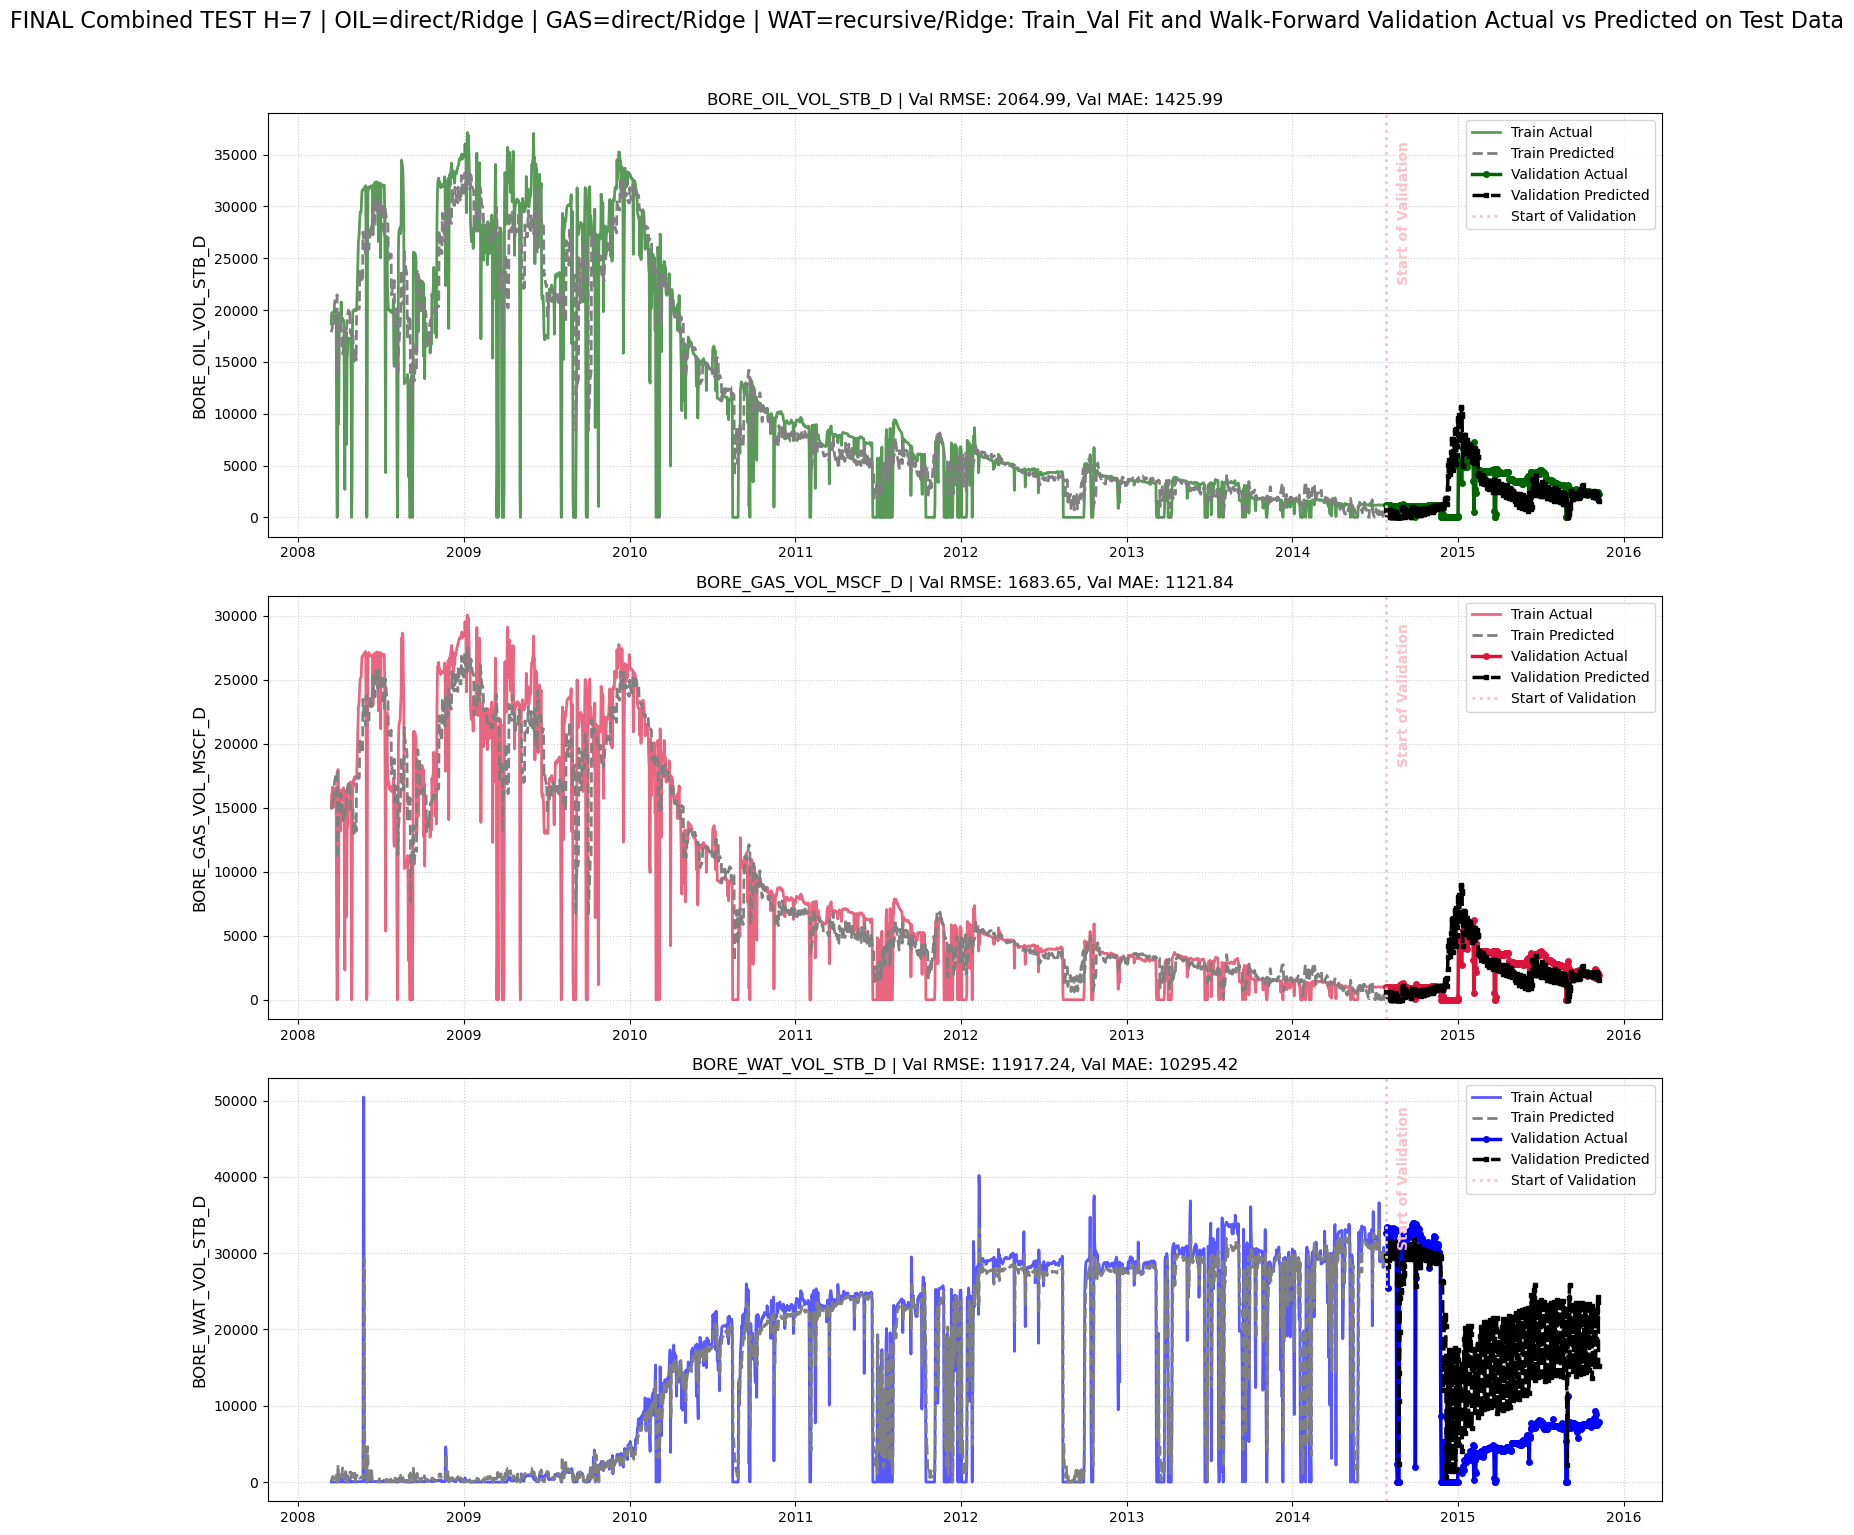

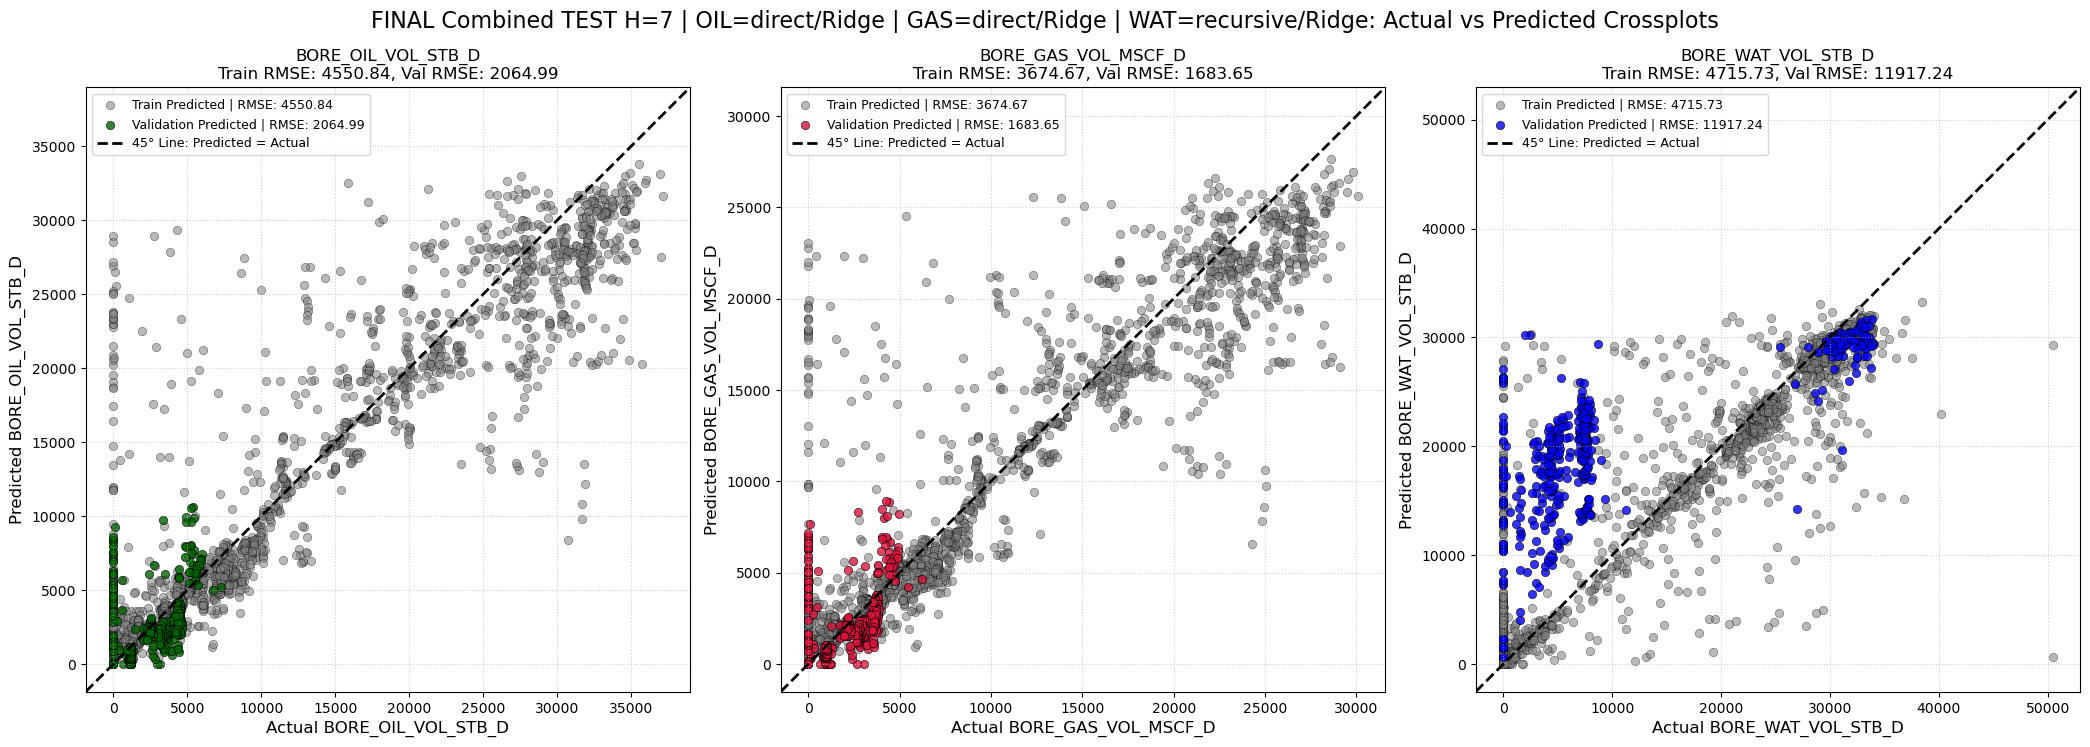

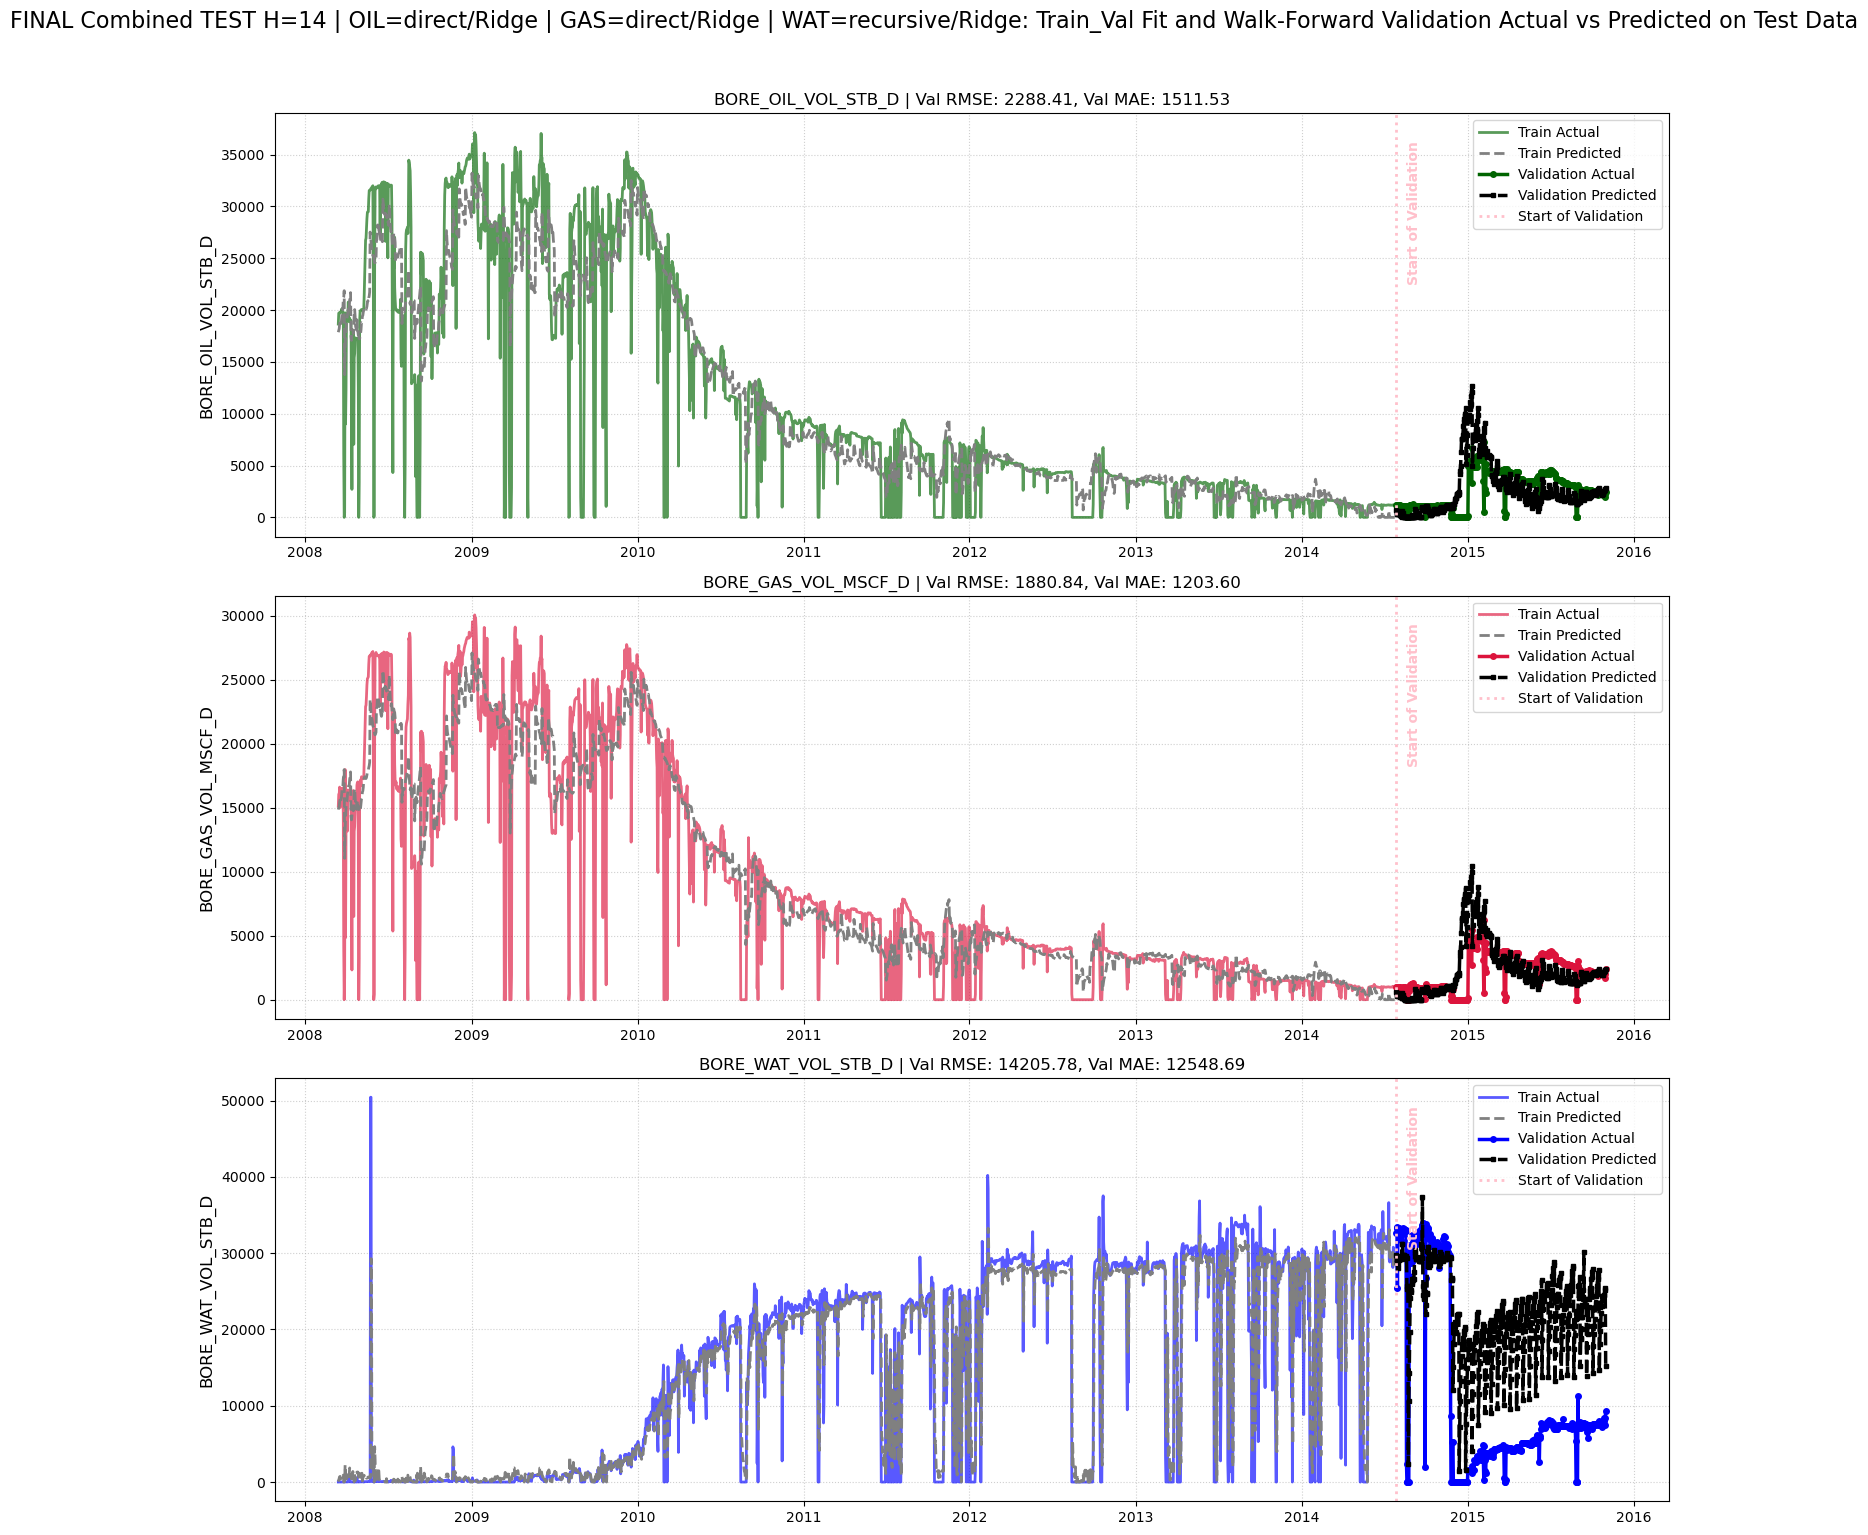

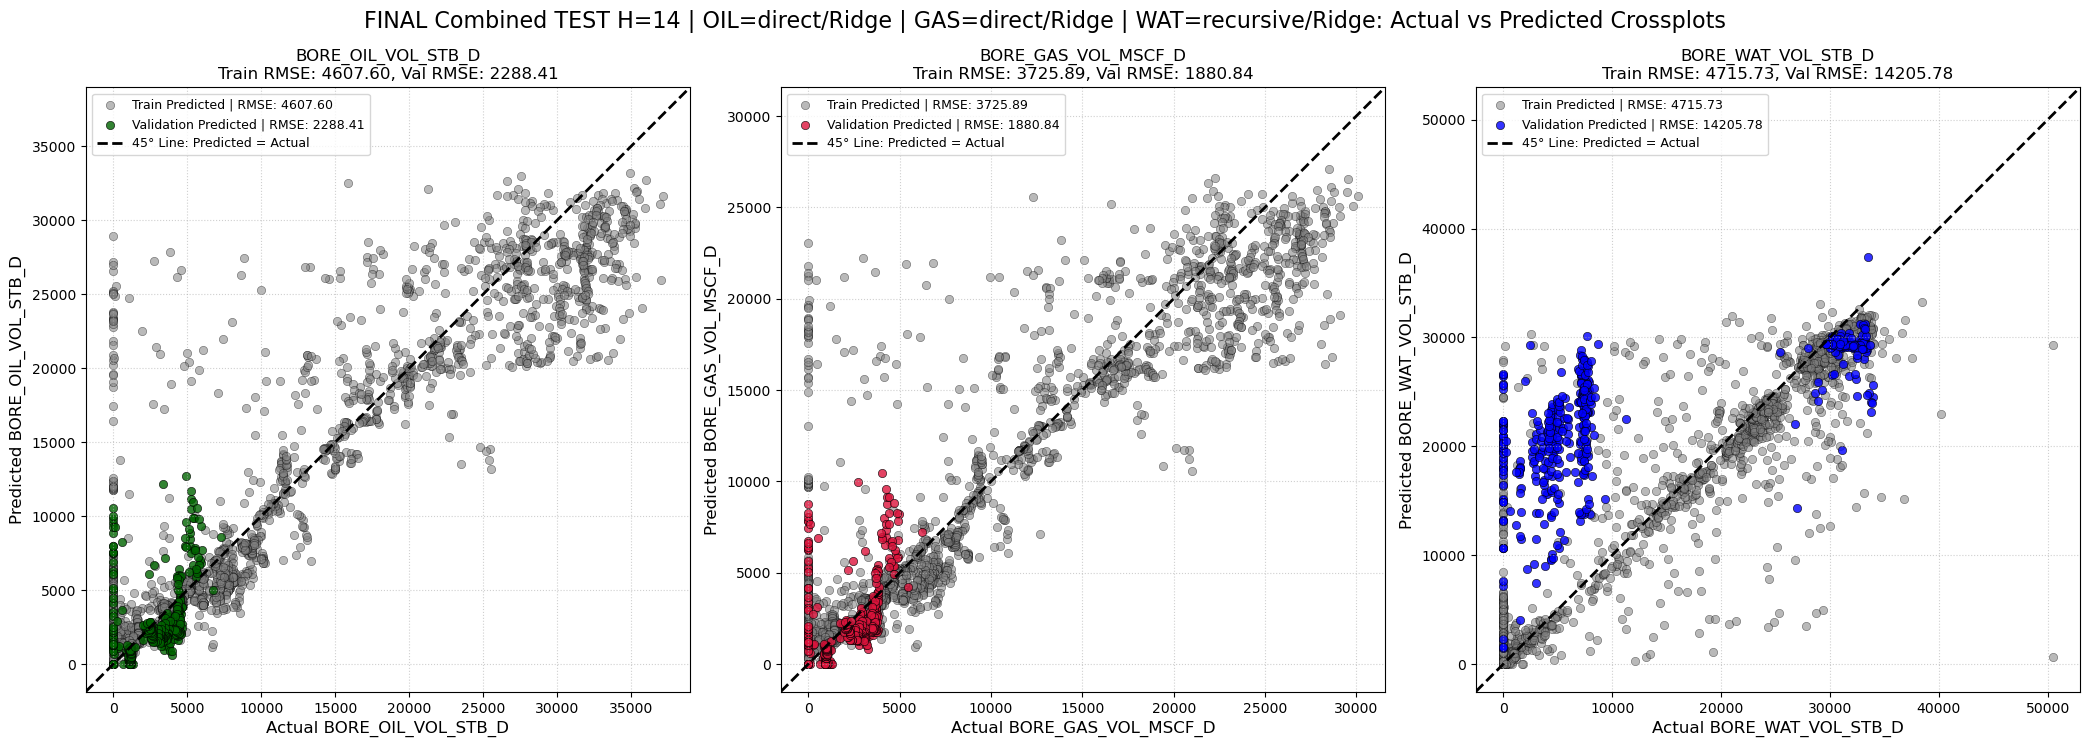

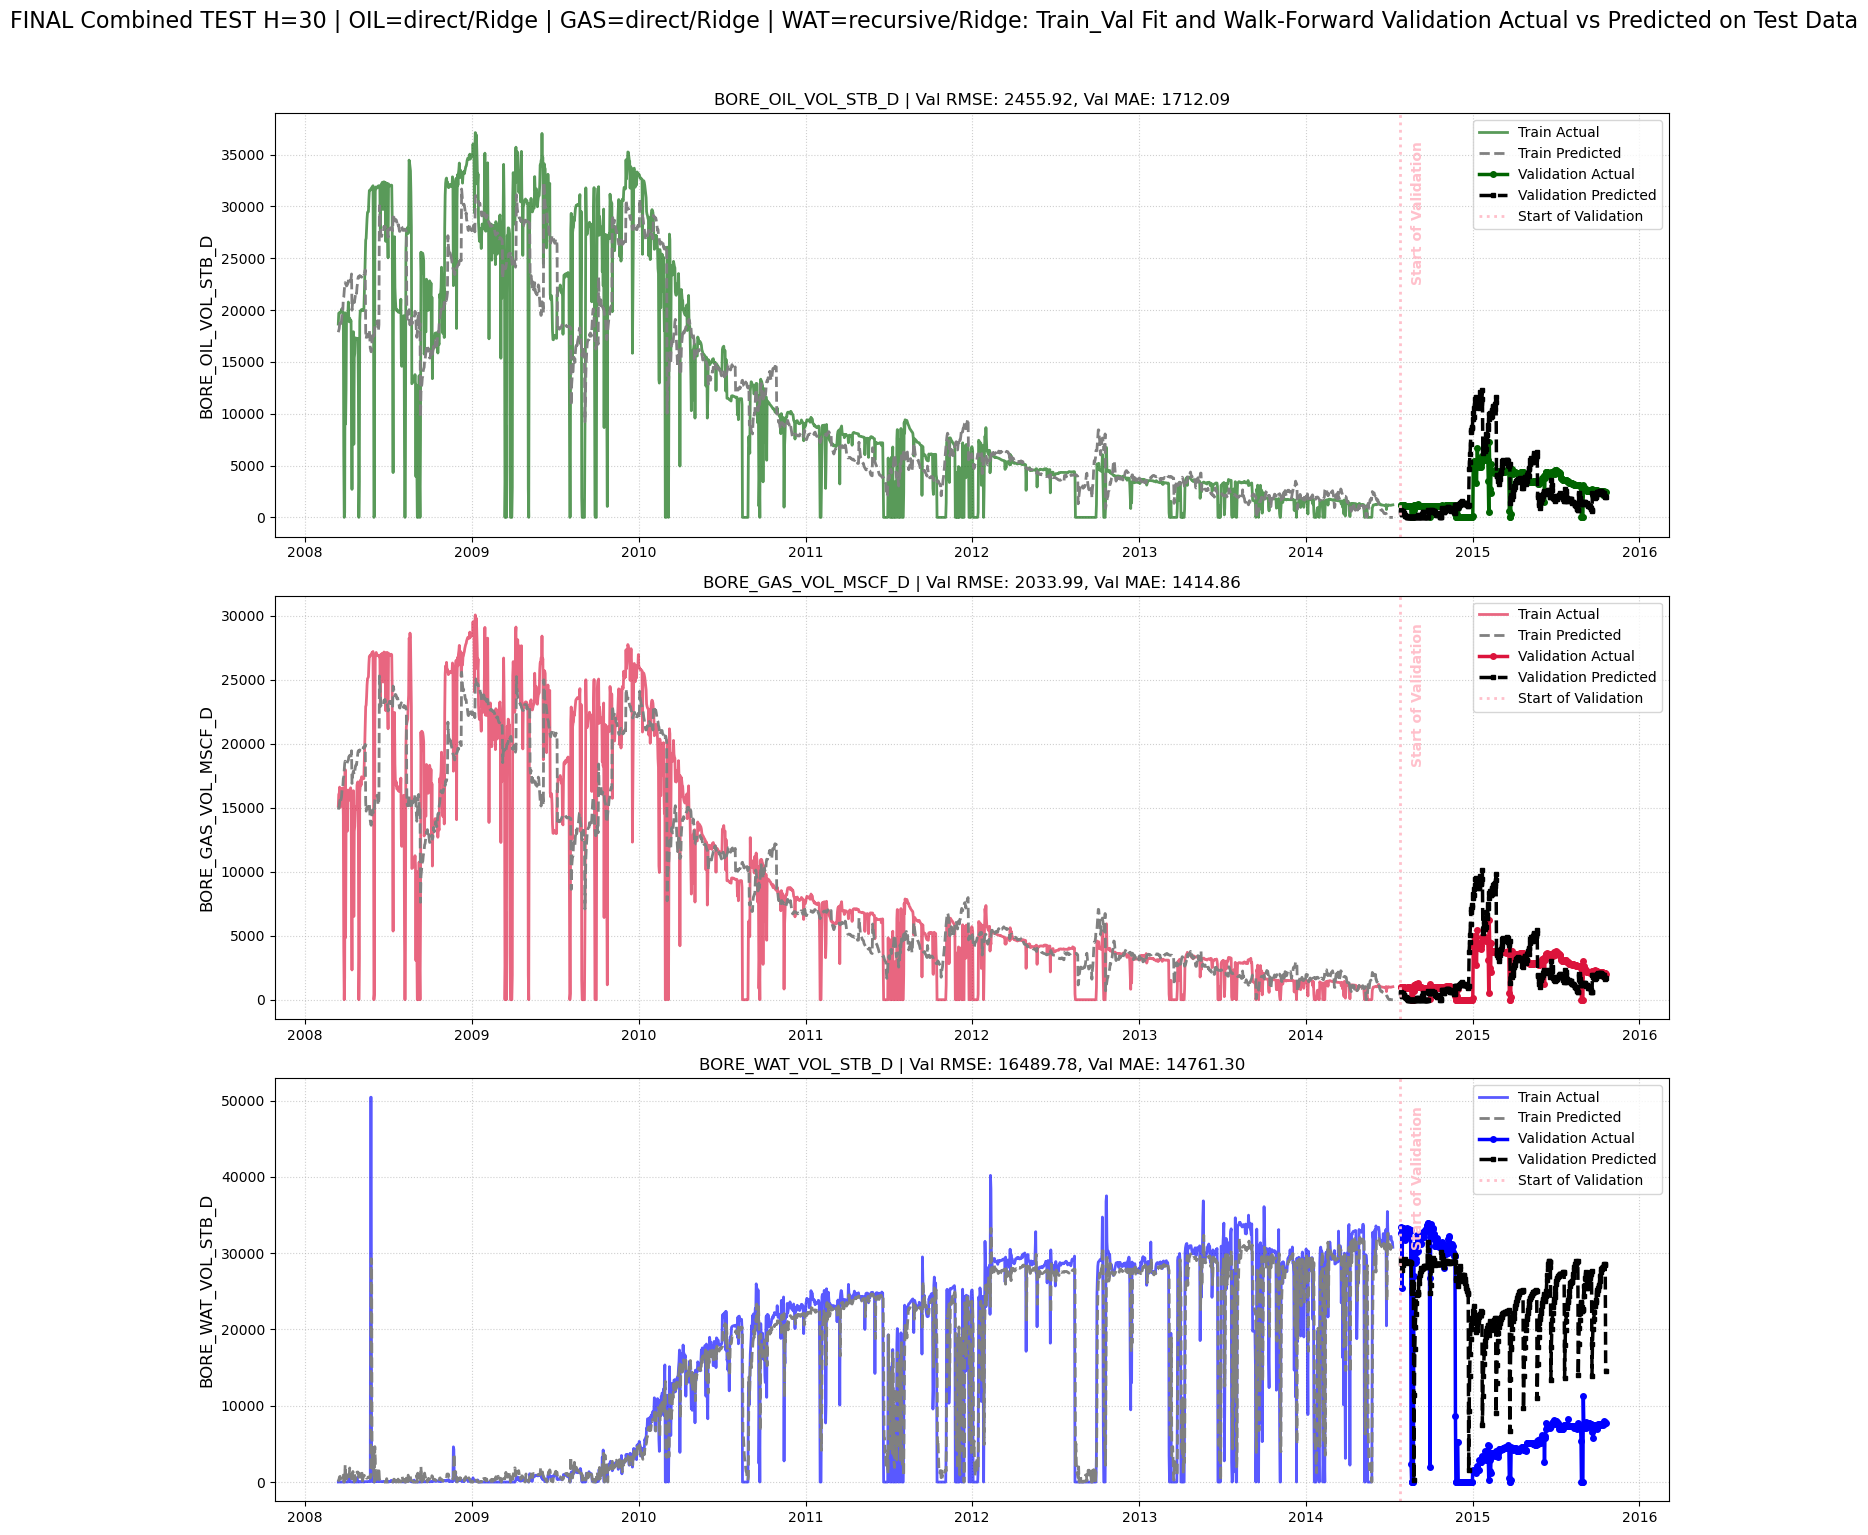

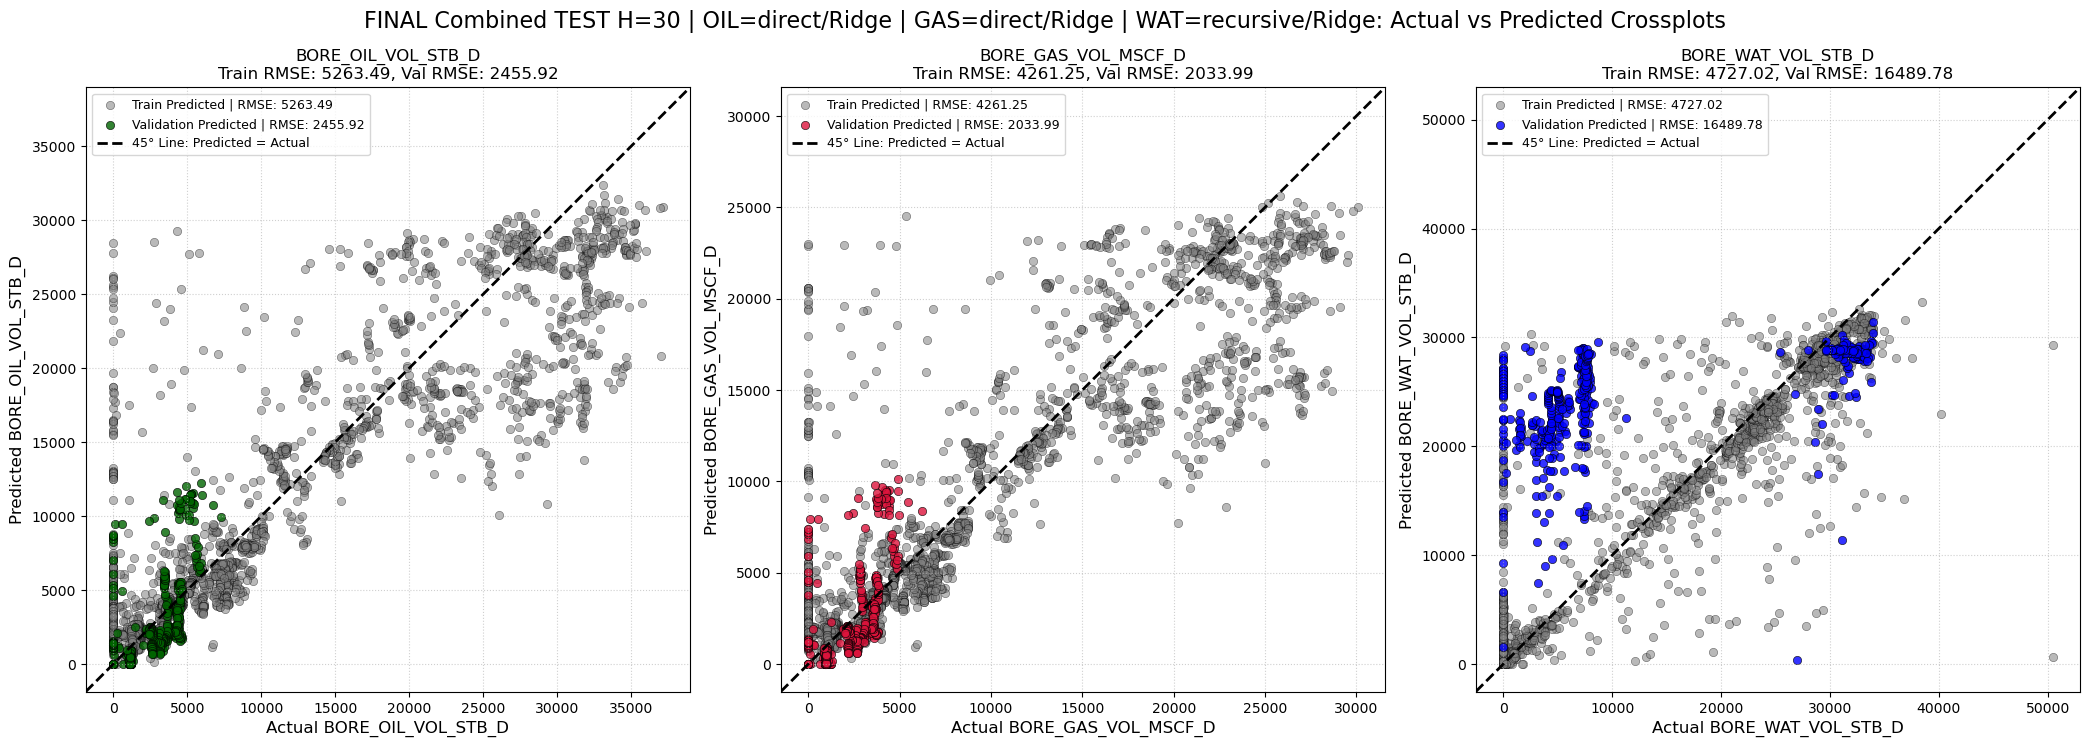

,Horizon,Model,Phase,Train_RMSE,Train_MAE,Train_R2,WalkForward_Val_RMSE,WalkForward_Val_MAE,WalkForward_Val_R2,Val_RMSE,Val_MAE,Val_R2
row,,,,,,,,,,,,
0,7,FINAL Combined TEST H=7 | OIL=direct/Ridge | G...,BORE_OIL_VOL_STB_D,4550.837350,2555.099088,0.832007,2064.988116,1425.988165,-0.534024,2064.988116,1425.988165,-0.534024
1,7,FINAL Combined TEST H=7 | OIL=direct/Ridge | G...,BORE_GAS_VOL_MSCF_D,3674.671704,2093.531193,0.825415,1683.647545,1121.842779,-0.512456,1683.647545,1121.842779,-0.512456
2,7,FINAL Combined TEST H=7 | OIL=direct/Ridge | G...,BORE_WAT_VOL_STB_D,4715.730096,2282.444469,0.864160,11917.243692,10295.419789,-0.042131,11917.243692,10295.419789,-0.042131
0,14,FINAL Combined TEST H=14 | OIL=direct/Ridge | ...,BORE_OIL_VOL_STB_D,4607.600808,2658.931301,0.827790,2288.412288,1511.533168,-0.856869,2288.412288,1511.533168,-0.856869
1,14,FINAL Combined TEST H=14 | OIL=direct/Ridge | ...,BORE_GAS_VOL_MSCF_D,3725.892367,2181.891828,0.820514,1880.844000,1203.602399,-0.859953,1880.844000,1203.602399,-0.859953
2,14,FINAL Combined TEST H=14 | OIL=direct/Ridge | ...,BORE_WAT_VOL_STB_D,4715.730096,2282.444469,0.864160,14205.781360,12548.692524,-0.480816,14205.781360,12548.692524,-0.480816
0,30,FINAL Combined TEST H=30 | OIL=direct/Ridge | ...,BORE_OIL_VOL_STB_D,5263.486269,3266.323799,0.775469,2455.918336,1712.094267,-1.086429,2455.918336,1712.094267,-1.086429
1,30,FINAL Combined TEST H=30 | OIL=direct/Ridge | ...,BORE_GAS_VOL_MSCF_D,4261.249965,2655.686386,0.765365,2033.987358,1414.855074,-1.120922,2033.987358,1414.855074,-1.120922
2,30,FINAL Combined TEST H=30 | OIL=direct/Ridge | ...,BORE_WAT_VOL_STB_D,4727.022845,2288.886538,0.863190,16489.776365,14761.303578,-0.995264,16489.776365,14761.303578,-0.995264


In [16]:
combined_test_metrics = {}

for h in HORIZONS:
    picks = " | ".join(
        f"{p.split(chr(95))[1]}="
        f"{combined_choice[h][p]['Source']}/{combined_choice[h][p]['Model_Label']}"
        for p in target_cols
    )
    model_name = f"FINAL Combined TEST H={h} | {picks}"

    train_pred_df = combined_train_pred_df[h]
    y_train_plot = train_val_targets.loc[train_pred_df.index, target_cols]
    X_train_plot = pd.DataFrame(index=train_pred_df.index)   # only its index is used

    (_tr, _te, test_metrics_df) = plot_multi_phase_train_walkforward_val_diagnostics_FINAL(
        model=None,
        X_train=X_train_plot,
        y_train=y_train_plot,
        y_val=y_test,
        walk_forward_forecast_df=combined_test_forecast_df[h],
        target_cols=target_cols,
        model_name=model_name,
        start_of_val_date=start_of_test_date,
        clip_negative=True,
        make_combined_plots=True,
        walk_forward_metrics_df=combined_test_wf_metrics[h],
        train_pred_df=train_pred_df,
    )
    combined_test_metrics[h] = test_metrics_df

final_combined_test_summary = pd.concat(
    combined_test_metrics.values(),
    keys=combined_test_metrics.keys(),
    names=["Horizon", "row"],
).reset_index(level=0)
final_combined_test_summary


## 4. Save the combined final selection

In [17]:
import os
os.makedirs("processed_inputs", exist_ok=True)

combined_final = {
    "well": "3-15-9-F-12",
    "combined_choice": combined_choice,          # horizon -> {phase: {Source, Model_Label, Val_MAE, Val_RMSE}}
    "validation_candidates": candidates,         # every candidate considered
    "final_choice_df": final_choice_df,          # tidy selection table
    "test_summary": combined_test_summary,       # test MAE / RMSE / R2 of the final model
}
out_path = "processed_inputs/combined_final_selection_3-15-9-F-12.joblib"
joblib.dump(combined_final, out_path)
print("Saved ->", out_path)
combined_test_summary


Saved -> processed_inputs/combined_final_selection_3-15-9-F-12.joblib


,Horizon,Phase,Source,Model_Label,Overridden,Test_MAE,Test_RMSE,Test_R2,N
0,7,BORE_OIL_VOL_STB_D,direct,Ridge,False,1425.988165,2064.988116,-0.534024,469
1,7,BORE_GAS_VOL_MSCF_D,direct,Ridge,False,1121.842779,1683.647545,-0.512456,469
2,7,BORE_WAT_VOL_STB_D,recursive,Ridge,False,10295.419789,11917.243692,-0.042131,471
3,14,BORE_OIL_VOL_STB_D,direct,Ridge,False,1511.533168,2288.412288,-0.856869,462
4,14,BORE_GAS_VOL_MSCF_D,direct,Ridge,False,1203.602399,1880.844000,-0.859953,462
5,14,BORE_WAT_VOL_STB_D,recursive,Ridge,False,12548.692524,14205.781360,-0.480816,471
6,30,BORE_OIL_VOL_STB_D,direct,Ridge,False,1712.094267,2455.918336,-1.086429,450
7,30,BORE_GAS_VOL_MSCF_D,direct,Ridge,False,1414.855074,2033.987358,-1.120922,450
8,30,BORE_WAT_VOL_STB_D,recursive,Ridge,False,14761.303578,16489.776365,-0.995264,471
